# Notebook 4: Ejecución y Costes

**Objetivo:** ejecutar el motor de backtesting event-driven sobre las señales
generadas en NB3, simulando las condiciones reales de mercado del enunciado.

**Reglas de ejecución (según el PDF):**
- **Ventas:** se ejecutan al precio **OPEN** del día de rebalanceo.
- **Compras:** se ejecutan al precio **CLOSE** del mismo día de rebalanceo.
- **Dimensionamiento:** la cantidad de acciones a comprar se calcula con el precio
  **Close de t-1** (día anterior) y se redondea a **acciones enteras** (`int()`),
  evitando look-ahead bias.
- **Costes:** 0,23 % sobre el valor efectivo con un mínimo estricto de **23 $** por orden.
- **Línea de crédito:** se permite descubierto temporal si el precio de ejecución
  (Close de t) difiere del precio de decisión (Close de t-1).
- **Delisting:** si un activo deja de cotizar, se vende al último precio close válido
  en el día en que se detecta el NaN.

**Flujo del notebook:**
1. Carga de datos (opens, closes, target_portfolios).
2. Motor de backtesting (`BacktestEngine`): ejecución doble — con y sin costes.
3. Visualización comparativa de equity curves.
4. Métricas de rendimiento (`BacktestMetrics`).
5. Registro de operaciones (trade log).
6. Comprobación de delistings.
7. Exportación de resultados para NB5.

**Inputs (de NB3):**
- `closes.parquet`, `opens.parquet` — precios wide (date × tickers)
- `target_portfolios.parquet` — pesos objetivo por fecha de rebalanceo

**Outputs:**
- `equity_costs.parquet` — equity curve con costes (para NB5)
- `equity_no_costs.parquet` — equity curve sin costes (para NB5)
- `logs_costs.parquet` — registro de operaciones con costes (para NB5)

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Estilo ──
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ── Rutas (robusto, sin hardcodear rutas absolutas) ──
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"

# ── Cargar datos de NB3 ──
opens = pd.read_parquet(DATA_DIR / "opens.parquet")
closes = pd.read_parquet(DATA_DIR / "closes.parquet")
target_portfolios = pd.read_parquet(DATA_DIR / "target_portfolios.parquet")

print(f"opens:             {opens.shape}")
print(f"closes:            {closes.shape}")
print(f"target_portfolios: {target_portfolios.shape}")
print(f"Primer rebalanceo: {target_portfolios.index[0].date()}")
print(f"Último rebalanceo: {target_portfolios.index[-1].date()}")

opens:             (9087, 1273)
closes:            (9087, 1273)
target_portfolios: (133, 416)
Primer rebalanceo: 2015-01-30
Último rebalanceo: 2026-01-30


## 1. Motor de Backtesting — `BacktestEngine`

El motor itera sobre cada día de trading en orden cronológico y, en cada
fecha de rebalanceo, ejecuta tres fases:

1. **Delisting check:** si el precio close de un activo en cartera es NaN,
   se vende al último precio close válido registrado.
2. **Ventas al OPEN:** se liquidan posiciones eliminadas o con exceso de peso.
   El valor de cartera se calcula a precios OPEN para dimensionar las ventas.
   Las ventas parciales se redondean a **acciones enteras** (`int()`).
3. **Compras al CLOSE:** se construyen las posiciones nuevas o deficitarias.
   La cantidad de acciones se calcula con el precio Close de **t-1** (día anterior)
   y se redondea a **acciones enteras** (`int()`). La ejecución se realiza al
   precio Close de **t** (día de rebalanceo). Si el efectivo queda negativo
   tras las compras, se permite un **descubierto temporal** (línea de crédito).

Al final de cada día se hace mark-to-market (valoración a precios close)
para registrar la equity curve.

La comisión por orden se calcula como:
```
comisión = max(23.0 $, valor_efectivo × 0.0023)
```

**Nota sobre realismo operativo:** Al usar acciones enteras y precios de t-1
para dimensionar, los pesos finales se desvían ligeramente del 5 % teórico.
Esta desviación es realista e intencional, ya que en mercados reales no se
pueden comprar fracciones de acciones y el precio de ejecución difiere del
precio de decisión.

Se ejecuta dos veces: una con costes y otra sin costes (`apply_costs=False`),
para aislar el impacto de las comisiones en el rendimiento.

### Lógica de Rebalanceo: Ajuste por Diferencial (Neto) con Acciones Enteras

Para optimizar la ejecución y reducir el impacto de las comisiones, el `BacktestEngine` implementa un rebalanceo por **diferencial neto** en lugar de una rotación completa de activos.

#### 1. Concepto de Operación
En lugar de cerrar una posición existente para volver a abrirla con el peso objetivo (lo cual generaría doble comisión y spread), el motor calcula la desviación respecto al peso ideal:

* **Si Peso Actual > Peso Objetivo (7% → 5%):** El motor identifica el excedente del **2%** y genera una orden de **VENTA** únicamente por esa fracción en la apertura (**OPEN**), redondeando a **acciones enteras** (`int()`).
* **Si Peso Actual < Peso Objetivo (3% → 5%):** El motor identifica el déficit del **2%** y genera una orden de **COMPRA** por la diferencia en el cierre (**CLOSE**). La cantidad se calcula con el **precio Close de t-1** y se redondea a **acciones enteras**.
* **Si el Activo sale de la estrategia:** Se liquida el **100%** de la posición en el OPEN.

#### 2. Implementación en el Código

| Fase | Dimensionamiento | Ejecución | Redondeo |
| :--- | :--- | :--- | :--- |
| **Venta parcial (Open)** | `excess_val / p_open` | Al precio OPEN de t | `int()` (floor) |
| **Compra (Close)** | `deficit / p_prev_close` (precio t-1) | Al precio CLOSE de t | `int()` (floor) |
| **Venta total** | 100% de la posición | Al precio OPEN de t | Ya es entera |

#### 3. Realismo Operativo
* **Acciones enteras:** No se compran fracciones de acciones. Se aplica `int()` (redondeo hacia abajo) para obtener cantidades reales.
* **Precios de decisión vs ejecución:** La cantidad de acciones se decide con el Close de t-1 (información disponible), pero se ejecuta al Close de t. Esta diferencia genera una desviación natural del peso objetivo respecto al 5% teórico.
* **Línea de crédito:** Si el precio de ejecución (Close t) es mayor que el de dimensionamiento (Close t-1), el cash puede quedar temporalmente negativo. El motor lo permite en lugar de recortar compras.
* **Menor Turnover:** Solo se mueve el capital estrictamente necesario para cumplir con el target portfolio.

> **Nota:** El motor utiliza un peso objetivo fijo del **5%** por activo (equi-ponderado para 20 activos). Los pesos reales post-ejecución se desvían ligeramente por el redondeo y la diferencia de precios.

In [2]:
class BacktestEngine:
    """Motor de backtesting event-driven para la estrategia momentum.

    Itera día a día sobre los precios, ejecutando ventas al OPEN y compras
    al CLOSE en cada fecha de rebalanceo. Gestiona delistings y aplica la
    estructura de costes definida en el enunciado.

    Realismo operativo:
    - Las cantidades de acciones a comprar se calculan con el precio Close
      de t-1 (día anterior) y se redondean a enteros (int / floor).
    - La ejecución de compras se realiza al precio Close de t.
    - Se permite descubierto temporal (línea de crédito) si el cash queda
      negativo tras compras, dado que el precio de ejecución difiere del
      precio de dimensionamiento.
    """

    def __init__(
        self,
        opens: pd.DataFrame,
        closes: pd.DataFrame,
        target_portfolios: pd.DataFrame,
        initial_cash: float = 250_000.0,
        apply_costs: bool = True,
    ):
        self.opens = opens
        self.closes = closes
        self.target_portfolios = target_portfolios
        self.initial_cash = initial_cash
        self.apply_costs = apply_costs

    def _commission(self, value: float) -> float:
        """Comisión por orden: max(23 $, 0.23 % del valor efectivo)."""
        if not self.apply_costs:
            return 0.0
        return max(23.0, value * 0.0023)

    def run(self):
        """Ejecuta el backtest completo.

        Returns
        -------
        equity_df : pd.DataFrame
            Equity curve diaria (columna 'equity').
        logs_df : pd.DataFrame
            Registro de cada operación ejecutada.
        total_commissions : float
            Suma total de comisiones pagadas.
        snapshots : list[dict]
            Composición real de la cartera tras cada rebalanceo.
        """
        cash = self.initial_cash
        positions = {}  # ticker -> shares (enteras)
        last_valid_close = {}
        prev_day_close = {}  # Close del día anterior (para dimensionar compras)

        equity_curve = []
        logs = []
        snapshots = []  # composición real de la cartera por rebalanceo
        total_commissions = 0.0

        rebalance_dates = set(self.target_portfolios.index)
        trading_days = self.closes.index

        for t in trading_days:
            try:
                day_open = self.opens.loc[t]
                day_close = self.closes.loc[t]
            except KeyError:
                continue

            # ── Fase 1: Delisting check ──
            tickers_to_remove = []
            for ticker, shares in positions.items():
                if pd.isna(day_close.get(ticker, np.nan)):
                    sell_price = last_valid_close.get(ticker, 0.0)
                    if sell_price > 0:
                        sold_value = shares * sell_price
                        comm = self._commission(sold_value)
                        cash += (sold_value - comm)
                        total_commissions += comm
                        logs.append({
                            'date': t, 'type': 'DELIST_SELL',
                            'ticker': ticker, 'shares': shares,
                            'price': sell_price, 'value': sold_value,
                            'comm': comm,
                        })
                    tickers_to_remove.append(ticker)

            for ticker in tickers_to_remove:
                del positions[ticker]

            # Actualizar último close válido
            for ticker in positions.keys():
                if not pd.isna(day_close.get(ticker, np.nan)):
                    last_valid_close[ticker] = day_close[ticker]

            # ── Fase 2: Rebalanceo ──
            if t in rebalance_dates:
                target_weights = self.target_portfolios.loc[t]
                target_tickers = target_weights[target_weights > 0].index.tolist()

                # --- VENTAS AL OPEN ---
                pv_open = cash
                for ticker, shares in positions.items():
                    p_open = day_open.get(ticker, np.nan)
                    if pd.isna(p_open):
                        p_open = day_close.get(
                            ticker, last_valid_close.get(ticker, 0)
                        )
                    pv_open += shares * p_open

                target_value_per_asset = pv_open * 0.05

                sells_executed = {}
                for ticker in list(positions.keys()):
                    p_open = day_open.get(ticker, np.nan)
                    if pd.isna(p_open):
                        continue

                    if ticker not in target_tickers:
                        # Vender toda la posición (ya es entera)
                        sells_executed[ticker] = positions[ticker]
                    else:
                        # Vender el exceso si hay sobrepeso (acciones enteras)
                        current_val = positions[ticker] * p_open
                        if current_val > target_value_per_asset:
                            excess_val = current_val - target_value_per_asset
                            shares_to_sell = int(excess_val / p_open)
                            if shares_to_sell >= 1:
                                sells_executed[ticker] = shares_to_sell

                for ticker, shares_to_sell in sells_executed.items():
                    p_open = day_open[ticker]
                    sold_value = shares_to_sell * p_open
                    comm = self._commission(sold_value)
                    cash += (sold_value - comm)
                    total_commissions += comm
                    positions[ticker] -= shares_to_sell
                    if positions[ticker] < 1:
                        del positions[ticker]
                    logs.append({
                        'date': t, 'type': 'SELL', 'ticker': ticker,
                        'shares': shares_to_sell, 'price': p_open,
                        'value': sold_value, 'comm': comm,
                    })

                # --- COMPRAS AL CLOSE ---
                # Dimensionar con precios de t-1, ejecutar al close de t
                pv_close = cash
                for ticker, shares in positions.items():
                    p_close = day_close.get(ticker, np.nan)
                    if not pd.isna(p_close):
                        pv_close += shares * p_close

                target_value_per_asset_close = pv_close * 0.05

                buy_orders = []
                for ticker in target_tickers:
                    p_close = day_close.get(ticker, np.nan)
                    p_prev = prev_day_close.get(ticker, np.nan)
                    if pd.isna(p_close) or pd.isna(p_prev):
                        continue

                    current_val = positions.get(ticker, 0) * p_close
                    deficit = target_value_per_asset_close - current_val

                    if deficit > 0:
                        # Cantidad de acciones con precio t-1, redondeada abajo
                        shares_to_buy = int(deficit / p_prev)
                        if shares_to_buy < 1:
                            continue
                        # Valor de ejecución real al close de t
                        exec_value = shares_to_buy * p_close
                        comm = self._commission(exec_value)
                        buy_orders.append((ticker, shares_to_buy, exec_value, comm))

                # Ejecutar TODAS las compras (permitir cash negativo = línea de crédito)
                for ticker, shares_to_buy, exec_value, comm in buy_orders:
                    cash -= (exec_value + comm)
                    positions[ticker] = positions.get(ticker, 0) + shares_to_buy
                    total_commissions += comm
                    logs.append({
                        'date': t, 'type': 'BUY', 'ticker': ticker,
                        'shares': shares_to_buy, 'price': day_close[ticker],
                        'value': exec_value, 'comm': comm,
                    })

                # ── Snapshot post-rebalanceo ──
                snap = {}
                total_val = cash
                for tk, sh in positions.items():
                    pc = day_close.get(tk, np.nan)
                    if pd.isna(pc):
                        pc = last_valid_close.get(tk, 0)
                    val = sh * pc
                    snap[tk] = {'shares': sh, 'value': val}
                    total_val += val

                for tk in snap:
                    snap[tk]['weight'] = (
                        snap[tk]['value'] / total_val if total_val else 0
                    )

                snapshots.append({
                    'date': t, 'cash': cash, 'total_value': total_val,
                    'positions': snap,
                })

            # ── Fase 3: Mark to Market ──
            pv_today = cash
            for ticker, shares in positions.items():
                p_close = day_close.get(ticker, np.nan)
                if pd.isna(p_close):
                    p_close = last_valid_close.get(ticker, 0)
                pv_today += shares * p_close

            equity_curve.append({'date': t, 'equity': pv_today})

            # Guardar closes del día actual para el día siguiente (t-1)
            for ticker in self.closes.columns:
                val = day_close.get(ticker, np.nan)
                if not pd.isna(val):
                    prev_day_close[ticker] = val

        equity_df = pd.DataFrame(equity_curve).set_index('date')
        logs_df = pd.DataFrame(logs)

        return equity_df, logs_df, total_commissions, snapshots

In [3]:
# ── Ejecutar el motor dos veces: con y sin costes ──
engine_costs = BacktestEngine(opens, closes, target_portfolios, apply_costs=True)
engine_no_costs = BacktestEngine(opens, closes, target_portfolios, apply_costs=False)

equity_costs, logs_costs, comms_costs, snapshots_costs = engine_costs.run()
equity_no_costs, logs_no_costs, comms_no_costs, _ = engine_no_costs.run()

# Fecha de inicio real del backtest (primer rebalanceo con posiciones)
FIRST_REBALANCE = target_portfolios.index[0]

print(f"Comisiones totales (con costes):  ${comms_costs:,.2f}")
print(f"Equity final (con costes):        ${equity_costs['equity'].iloc[-1]:,.2f}")
print(f"Equity final (sin costes):        ${equity_no_costs['equity'].iloc[-1]:,.2f}")
print(f"Periodo del backtest:             {FIRST_REBALANCE.date()} → "
      f"{equity_costs.index[-1].date()}")

Comisiones totales (con costes):  $121,735.67
Equity final (con costes):        $698,506.00
Equity final (sin costes):        $975,678.62
Periodo del backtest:             2015-01-30 → 2026-01-30


### Composición Real de la Cartera por Rebalanceo

Tras ejecutar con acciones enteras y precios de t-1, los pesos reales
se desvían del 5 % teórico. A continuación se analiza la distribución
de pesos en cada fecha de rebalanceo para auditar el impacto del
redondeo y la diferencia entre precio de decisión y precio de ejecución.

In [4]:
def build_weights_df(snapshots):
    """Construye DataFrame (date × ticker) con pesos reales post-rebalanceo."""
    rows = []
    for snap in snapshots:
        row = {'date': snap['date'],
               'cash_weight': snap['cash'] / snap['total_value']}
        for tk, info in snap['positions'].items():
            row[tk] = info['weight']
        rows.append(row)
    return pd.DataFrame(rows).set_index('date').fillna(0.0)


weights_real = build_weights_df(snapshots_costs)

# Estadísticas de desviación respecto al 5 % teórico
active = weights_real.drop(columns=['cash_weight']).replace(0, np.nan)

stats = pd.DataFrame({
    'Media peso (%)':   (active.mean(axis=1) * 100).round(3),
    'Std peso (%)':     (active.std(axis=1) * 100).round(3),
    'Min peso (%)':     (active.min(axis=1) * 100).round(3),
    'Max peso (%)':     (active.max(axis=1) * 100).round(3),
    'Cash (%)':         (weights_real['cash_weight'] * 100).round(3),
    'Num activos':       active.notna().sum(axis=1),
})

print("Pesos reales por fecha de rebalanceo (objetivo teórico: 5.000 %):")
display(stats)

Pesos reales por fecha de rebalanceo (objetivo teórico: 5.000 %):


,Media peso (%),Std peso (%),Min peso (%),Max peso (%),Cash (%),Num activos
date,,,,,,
2015-01-30,4.887,0.075,4.717,4.992,2.265,20
2015-02-27,4.993,0.054,4.893,5.092,0.145,20
2015-03-31,4.982,0.055,4.813,5.087,0.355,20
2015-04-30,4.996,0.043,4.916,5.085,0.086,20
2015-05-29,5.017,0.063,4.946,5.210,-0.330,20
...,...,...,...,...,...,...
2025-09-30,5.004,0.093,4.844,5.226,-0.089,20
2025-10-31,5.031,0.082,4.882,5.196,-0.614,20
2025-11-28,5.052,0.115,4.974,5.513,-1.050,20


In [5]:
def show_portfolio(snapshots, date):
    """Muestra composición detallada de la cartera en una fecha de rebalanceo."""
    snap = next(s for s in snapshots if s['date'] == date)
    data = []
    for tk, info in snap['positions'].items():
        data.append({
            'ticker': tk,
            'shares': info['shares'],
            'value ($)': round(info['value'], 2),
            'weight (%)': round(info['weight'] * 100, 3),
            'dev vs 5% (pp)': round((info['weight'] - 0.05) * 100, 3),
        })
    df = pd.DataFrame(data).sort_values('weight (%)', ascending=False)
    cash_pct = snap['cash'] / snap['total_value'] * 100
    print(f"Cartera al {date.date()} — Total: ${snap['total_value']:,.2f} | "
          f"Cash: ${snap['cash']:,.2f} ({cash_pct:.2f}%)")
    display(df.reset_index(drop=True))


# Ejemplo: último rebalanceo
show_portfolio(snapshots_costs, snapshots_costs[-1]['date'])

Cartera al 2026-01-30 — Total: $698,506.00 | Cash: $2,682.96 (0.38%)


,ticker,shares,value ($),weight (%),dev vs 5% (pp)
0,CHRW,186,36260.699219,5.191,0.191
1,ALB,212,36173.558594,5.179,0.179
2,GLW,344,35518.000000,5.085,0.085
3,FIX,31,35405.101562,5.069,0.069
4,TER,145,34952.250000,5.004,0.004
5,WBD,1268,34920.718750,4.999,-0.001
6,INTC,751,34898.968750,4.996,-0.004
7,MU,84,34849.921875,4.989,-0.011
8,GOOGL,103,34814.000000,4.984,-0.016
9,AMD,147,34799.308594,4.982,-0.018


## 2. Comparativa Gráfica: Con Costes vs Sin Costes

La siguiente gráfica muestra la evolución del capital desde el primer
rebalanceo, comparando la estrategia **con costes** de transacción
frente a la misma estrategia **sin costes**.

La diferencia entre ambas curvas representa el impacto acumulado de las
comisiones a lo largo del horizonte de inversión.

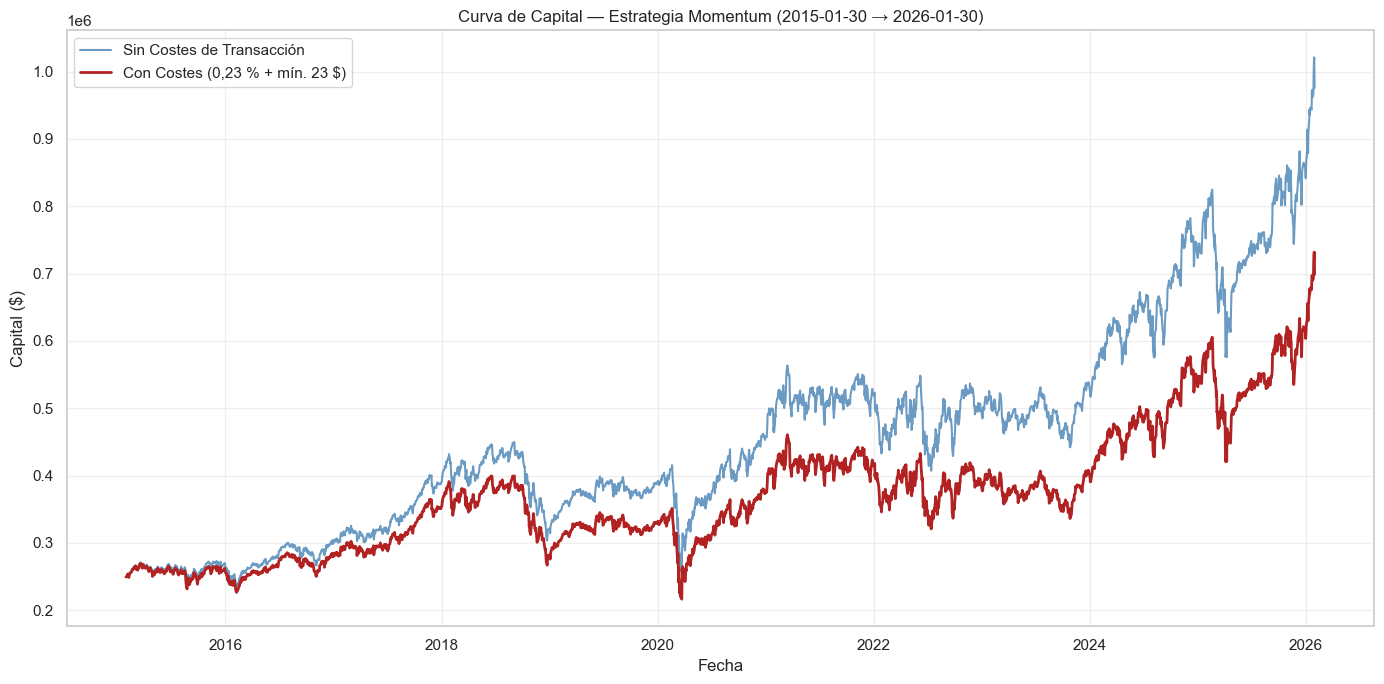

In [6]:
# Filtrar al periodo real del backtest (desde el primer rebalanceo)
ec_costs = equity_costs.loc[equity_costs.index >= FIRST_REBALANCE]
ec_no_costs = equity_no_costs.loc[equity_no_costs.index >= FIRST_REBALANCE]

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(
    ec_no_costs.index, ec_no_costs['equity'],
    label='Sin Costes de Transacción', color='steelblue', alpha=0.8,
)
ax.plot(
    ec_costs.index, ec_costs['equity'],
    label='Con Costes (0,23 % + mín. 23 $)', color='firebrick', linewidth=2,
)
ax.set_title(
    f'Curva de Capital — Estrategia Momentum '
    f'({FIRST_REBALANCE.strftime("%Y-%m-%d")} → '
    f'{ec_costs.index[-1].strftime("%Y-%m-%d")})'
)
ax.set_ylabel('Capital ($)')
ax.set_xlabel('Fecha')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Métricas de Rendimiento — `BacktestMetrics`

Se calculan las métricas principales sobre la ventana real del backtest
(desde el primer rebalanceo hasta la última fecha disponible).

| Métrica | Descripción |
|---|---|
| **Total Return** | Ganancia porcentual sobre el capital inicial |
| **CAGR** | Tasa de crecimiento anual compuesta |
| **Max Drawdown** | Mayor caída pico-a-valle de la equity curve |

In [7]:
class BacktestMetrics:
    """Calcula métricas de rendimiento sobre una equity curve.

    Parameters
    ----------
    equity_series : pd.Series
        Serie diaria de valor de cartera.
    start_date : pd.Timestamp
        Fecha de inicio de la ventana de análisis (se descartan días previos).
    """

    def __init__(self, equity_series: pd.Series, start_date: pd.Timestamp):
        self.equity = equity_series.loc[equity_series.index >= start_date]

    def total_return(self) -> float:
        return (self.equity.iloc[-1] / self.equity.iloc[0]) - 1

    def cagr(self) -> float:
        years = (self.equity.index[-1] - self.equity.index[0]).days / 365.25
        return (1 + self.total_return()) ** (1 / years) - 1 if years > 0 else np.nan

    def max_drawdown(self) -> float:
        rolling_max = self.equity.cummax()
        drawdown = (self.equity - rolling_max) / rolling_max
        return drawdown.min()

    def summary(self) -> dict:
        return {
            'Total Return': f"{self.total_return() * 100:.2f}%",
            'CAGR':         f"{self.cagr() * 100:.2f}%",
            'Max Drawdown': f"{self.max_drawdown() * 100:.2f}%",
        }


metrics_df = pd.DataFrame({
    'Con Costes':  BacktestMetrics(equity_costs['equity'], FIRST_REBALANCE).summary(),
    'Sin Costes':  BacktestMetrics(equity_no_costs['equity'], FIRST_REBALANCE).summary(),
}).T

display(metrics_df)

,Total Return,CAGR,Max Drawdown
Con Costes,180.03%,9.81%,-45.83%
Sin Costes,290.27%,13.18%,-42.86%


## 4. Registro de Operaciones (Trade Log)

Se muestran las primeras y últimas 10 operaciones del backtest con costes.
Cada fila representa una orden ejecutada, con su tipo (`BUY` / `SELL` / `DELIST_SELL`),
ticker, volumen, precio, valor efectivo y comisión aplicada.

La columna `shares` contiene siempre **números enteros** (acciones reales, sin
fracciones), resultado de aplicar `int()` al dimensionamiento.

In [8]:
print(f"Total operaciones ejecutadas: {len(logs_costs):,}")
print("\nDesglose por tipo:")
print(logs_costs['type'].value_counts().to_string())

print("\n── Primeras 10 operaciones ──")
display(logs_costs.head(10))

print("\n── Últimas 10 operaciones ──")
display(logs_costs.tail(10))

Total operaciones ejecutadas: 3,686

Desglose por tipo:
type
BUY            1927
SELL           1746
DELIST_SELL      13

── Primeras 10 operaciones ──


,date,type,ticker,shares,price,value,comm
0,2015-01-30,BUY,AGN-201503,56,219.212708,12275.912109,28.234598
1,2015-01-30,BUY,AMGN,109,110.880135,12085.934570,27.797649
2,2015-01-30,BUY,AVGO,1531,7.880504,12065.050781,27.749617
3,2015-01-30,BUY,BBWI,265,46.155460,12231.197266,28.131754
4,2015-01-30,BUY,CFN-201503,209,59.299999,12393.700195,28.505510
5,2015-01-30,BUY,DAL,284,41.431156,11766.448242,27.062832
6,2015-01-30,BUY,EA,232,53.340034,12374.887695,28.462242
7,2015-01-30,BUY,EW,580,20.891645,12117.154297,27.869455
8,2015-01-30,BUY,HCA,185,65.956566,12201.964844,28.064520
9,2015-01-30,BUY,KR,445,27.919355,12424.113281,28.575460



── Últimas 10 operaciones ──


,date,type,ticker,shares,price,value,comm
3676,2026-01-30,BUY,INTC,15,46.470001,697.050049,23.000000
3677,2026-01-30,BUY,IVZ,1260,27.290001,34385.402344,79.086426
3678,2026-01-30,BUY,LRCX,1,233.460007,233.460007,23.000000
3679,2026-01-30,BUY,MU,3,414.880005,1244.640015,23.000000
3680,2026-01-30,BUY,NEM,13,112.349998,1460.549927,23.000000
3681,2026-01-30,BUY,PLTR,67,146.589996,9821.529297,23.000000
3682,2026-01-30,BUY,STX,4,407.690002,1630.760010,23.000000
3683,2026-01-30,BUY,TPR,274,126.910004,34773.339844,79.978683
3684,2026-01-30,BUY,WBD,204,27.540001,5618.160156,23.000000
3685,2026-01-30,BUY,WDC,8,250.229996,2001.839966,23.000000


## 5. Comprobación de Delistings

Se verifican los eventos de venta forzada por delisting registrados durante el backtest.
A continuación se muestra el caso de Nielsen Holdings (NLSN-202210), que dejó de cotizar
en octubre de 2022, como ejemplo representativo del mecanismo implementado.

In [9]:
# ── Resumen de todos los eventos de delisting ──
delisting = logs_costs[logs_costs['type'] == 'DELIST_SELL']
print(f"Total eventos de delisting detectados: {len(delisting)}")
display(delisting)

# ── Caso de estudio: Nielsen Holdings (NLSN-202210) ──
# NLSN fue adquirida y dejó de cotizar en octubre de 2022.
# Verificamos que el motor vendió la posición al último precio close válido
# antes de que el ticker desapareciera, generando correctamente la comisión.
nlsn_ops = logs_costs[logs_costs['ticker'] == 'NLSN-202210']
print("\nOperaciones de NLSN-202210 (compra + venta forzada por delisting):")
display(nlsn_ops)

Total eventos de delisting detectados: 13


,date,type,ticker,shares,price,value,comm
48,2015-03-17,DELIST_SELL,AGN-201503,56,240.220001,13452.320312,30.940338
159,2015-07-06,DELIST_SELL,KRFT-201507,151,88.190002,13316.690430,30.628389
211,2015-09-03,DELIST_SELL,HSP-201509,137,89.949997,12323.149414,28.343245
289,2015-12-28,DELIST_SELL,ALTR-201512,250,53.959999,13490.000000,31.027000
319,2016-01-15,DELIST_SELL,CB-201601,98,127.260002,12471.480469,28.684406
432,2016-05-12,DELIST_SELL,SNDK-201605,166,76.180000,12645.879883,29.085524
433,2016-05-23,DELIST_SELL,ARG-201605,90,142.949997,12865.500000,29.590651
462,2016-06-21,DELIST_SELL,CVC-201606,376,34.869999,13111.119141,30.155575
1220,2018-09-12,DELIST_SELL,XL-201809,346,57.590000,19926.140625,45.830124
1248,2018-10-01,DELIST_SELL,ANDV-201809,126,153.500000,19341.000000,44.484303



Operaciones de NLSN-202210 (compra + venta forzada por delisting):


,date,type,ticker,shares,price,value,comm
2592,2022-09-30,BUY,NLSN-202210,630,27.719999,17463.599609,40.166279
2596,2022-10-12,DELIST_SELL,NLSN-202210,630,27.980000,17627.400391,40.543022


## 6. Exportar Resultados para NB5

Se guardan las equity curves (con y sin costes) y el registro de operaciones
como parquet en `/data/` para su consumo directo por el Notebook 5
(Comparativa, Monte Carlo y Análisis Crítico).

In [10]:
# Filtrar al periodo real del backtest antes de guardar
equity_costs_export = equity_costs.loc[equity_costs.index >= FIRST_REBALANCE]
equity_no_costs_export = equity_no_costs.loc[equity_no_costs.index >= FIRST_REBALANCE]

# ── Equity curves ──
equity_costs_path = DATA_DIR / "equity_costs.parquet"
equity_costs_export.to_parquet(equity_costs_path)

equity_no_costs_path = DATA_DIR / "equity_no_costs.parquet"
equity_no_costs_export.to_parquet(equity_no_costs_path)

# ── Trade log ──
logs_costs_path = DATA_DIR / "logs_costs.parquet"
logs_costs.to_parquet(logs_costs_path)

# ── Resumen ──
for name, path in [("equity_costs", equity_costs_path),
                    ("equity_no_costs", equity_no_costs_path),
                    ("logs_costs", logs_costs_path)]:
    size_kb = path.stat().st_size / 1e3
    print(f"  {name + '.parquet':<25s} ({size_kb:.1f} KB)")

print(f"\nPeriodo equity:  {equity_costs_export.index[0].date()} → "
      f"{equity_costs_export.index[-1].date()}")
print(f"Días de trading: {len(equity_costs_export):,}")
print(f"Operaciones:     {len(logs_costs):,}")

  equity_costs.parquet      (46.6 KB)
  equity_no_costs.parquet   (46.6 KB)
  logs_costs.parquet        (77.2 KB)

Periodo equity:  2015-01-30 → 2026-01-30
Días de trading: 2,767
Operaciones:     3,686
